<a href="https://colab.research.google.com/github/Dathu-03184/DL_Lab-Programs/blob/main/10%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Linear Regression Classifier Performance ===
Accuracy: 0.867

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.78      0.78      0.78         9
   virginica       0.82      0.82      0.82        11

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



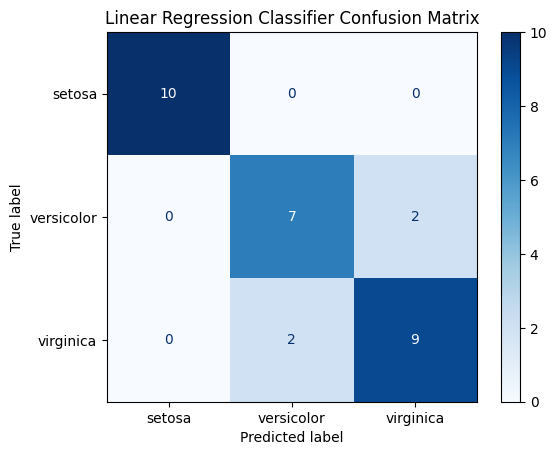

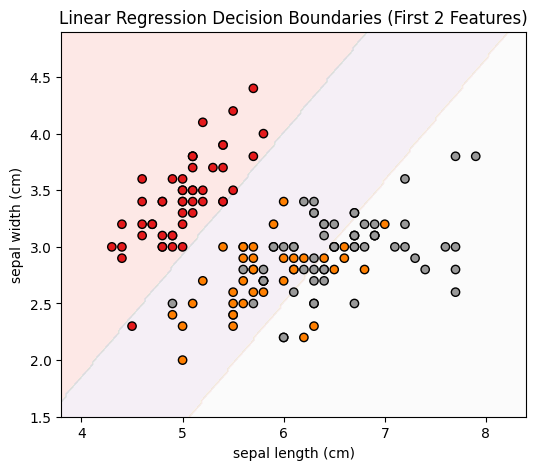

In [1]:
# 10 program
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1️⃣ Load dataset
data = load_iris()
X = data.data[:, :2]  # use first 2 features for visualization
y = data.target        # 3 classes

# 2️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3️⃣ Train Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# 4️⃣ Predict and convert to nearest integer class
y_pred_cont = lin_model.predict(X_test)
y_pred = np.rint(y_pred_cont).astype(int)
y_pred = np.clip(y_pred, 0, len(np.unique(y))-1)  # ensure valid class labels

# 5️⃣ Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("=== Linear Regression Classifier Performance ===")
print(f"Accuracy: {accuracy:.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# 6️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Linear Regression Classifier Confusion Matrix")
plt.show()

# 7️⃣ Visualize Decision Boundaries
h = 0.02
x_min, x_max = X[:, 0].min()-0.5, X[:,0].max()+0.5
y_min, y_max = X[:, 1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = lin_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.rint(Z).astype(int)
Z = np.clip(Z, 0, len(np.unique(y))-1)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Pastel1)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap=plt.cm.Set1)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Linear Regression Decision Boundaries (First 2 Features)")
plt.show()
